# Wind → layer-0 · Hazard definition — *the layer we never needed before*

**Peril:** Wind (strong/straight-line + tornado) · **Layer:** layer-0 (the **authored** hazard definition, *above* M0).

For hail and wildfire the hazard **event** came pre-defined by the data product, so this layer was empty. For
wind it is the **centerpiece**: no single product hands us "a wind event," so **we author the definition** —
quantitatively, anchored in engineering and meteorological standards. This notebook *codifies* that authored
definition and *teaches* the concepts it rests on, with executable math and known-answer checks.

> This is **not** an exploratory-*data* notebook (there is no data source to profile — M0 does that). It is a
> **definition** notebook: the discipline here is [*basics-spot-on*](../../../docs/principles/basics_spot_on.md)
> applied to the hazard's own definition — every number traces to a published standard (provenance flagged), and
> the one piece of real math (the bounded-GPD solve) is verified against known answers.

> Plan-of-record: [`00_hazard_definition.md`](../../../docs/plans/convective_wind/00_hazard_definition.md) · Reasoning:
> [`discussion/convective_wind/03`](../../../docs/extra/discussion/convective_wind/03_hazard_definition_and_thresholds.md) (standards)
> + [`discussion/convective_wind/02`](../../../docs/extra/discussion/convective_wind/02_coupling_buckets_and_wind.md) (coupling) ·
> Decisions [`DD-WN-*`](../../../docs/plans/convective_wind/decisions.md) · Assumptions [`AWN-*`](../../../docs/plans/convective_wind/assumptions.md).

## 0 · Intent & scope

**Does:** author the wind hazard **quantitatively** — the magnitude observable (3-s gust), the event-count
threshold μ + the EF bins, the physical bound L, the **bounded-GPD severity form** (with a verified analytic
solve), the **two-threshold** structure (event-count vs asset damage-onset), the **coupling-taxonomy primer**,
and the **anchored damage-curve** concept. Every choice is tagged with its provenance.

**Does NOT:** fetch any data, fit a frequency λ, choose a primary source, or compute loss — those are M0→M4. The
illustrative GPD μ_mean and the schematic damage curve here are **definitional placeholders**: M1 fits μ_mean to
the real (bias-corrected) gust record, M3 builds the real subsystem curve. This notebook fixes the *form*, not
the fitted parameters.

**Provenance legend** (honesty discipline, per [`docs/references`](../../../docs/references/README.md)):
`[REF]` = from the **Hazard-Data-Reference** · `[STD]` = a named external standard · `[FRAME]` = settled
framing / old-repo `HAZARD_LIMITS` (**not** in the reference — labeled honestly).

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import genpareto

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

MS_TO_MPH = 2.2369362921
MPH_TO_MS = 1.0 / MS_TO_MPH
def mph(ms): return ms * MS_TO_MPH
def ms(mph_): return mph_ * MPH_TO_MS

## 1 · Why this layer exists — the first peril we must *author*

For every prior peril, the **data product itself defined the event** and we simply inherited it. Wind has no
such product — the data is *fragmented*, and none of the pieces says "here is a wind event and its magnitude":

In [2]:
why = pd.DataFrame([
    ("Hail", "MRMS / MESH", "“severe hail = ≥ 1 inch” — event + threshold + magnitude metric, all baked in", "INHERITED"),
    ("Wildfire", "FSim (BP + FLP)", "“fire occurrence + flame-length classes” — event + conditional severity, pre-integrated", "INHERITED"),
    ("Wind", "— none —", "SPC reports · NOAA episodes · ASCE design surface · IEC turbine ratings · EF damage→wind map — fragmented", "AUTHORED ← here"),
], columns=["peril", "data product", "what defines the event", "layer-0"])
print(why.to_string(index=False))
print("\n→ Because no product hands us 'a wind event', WE define what counts as an event, at what threshold,")
print("  on what magnitude scale, bounded where — anchored in standards, not intuition. That is layer-0.")

   peril    data product                                                                                    what defines the event         layer-0
    Hail     MRMS / MESH                             “severe hail = ≥ 1 inch” — event + threshold + magnitude metric, all baked in       INHERITED
Wildfire FSim (BP + FLP)                   “fire occurrence + flame-length classes” — event + conditional severity, pre-integrated       INHERITED
    Wind        — none — SPC reports · NOAA episodes · ASCE design surface · IEC turbine ratings · EF damage→wind map — fragmented AUTHORED ← here

→ Because no product hands us 'a wind event', WE define what counts as an event, at what threshold,
  on what magnitude scale, bounded where — anchored in standards, not intuition. That is layer-0.


## 2 · The magnitude observable — the 3-second peak gust (from the very basics)  (AWN-5, DD-WN-6)

This is **THE** central variable: every threshold, the severity distribution, and the damage curve all live on
this one axis. So define it from scratch.

**1. Wind speed is always an average over a time window.** An anemometer never reports an "instantaneous" value
— it reports the wind *averaged over some interval*. **Which interval changes the number**, so the window is
part of the definition. Two windows matter for us:
- the **sustained wind** — a **1- or 10-minute mean** (the slowly-varying background flow); and
- the **gust** — a brief **peak** riding on top of it.

**2. The 3-second gust** = the highest wind speed averaged over any **3-second** interval during the event.
*Why 3 seconds?* It is the structural-engineering standard: short enough to capture the peak, yet long enough
that the gust front physically **envelops a whole structure** (it loads the entire turbine, not just a blade
tip). `[REF]` *"3-second gust speed is the universal metric — map it to a wind-load / fragility curve per asset."*

**3. Why the gust — not the mean — is the *damage* metric.** Structural / aerodynamic load is the **dynamic
pressure** `q = ½·ρ·V²`: it scales with the **square** of wind speed. A gust ~1.4× the mean therefore exerts
**~2×** the load — the brief peak dominates *failure*, the average barely matters. (The **mean** wind is the
*resource* metric that drives **generation** — the Performance tier, `model-gpr`; the **peak gust** drives
**damage** — this tier. Same medium, different question — [discussion/01 §7](../../../docs/extra/discussion/convective_wind/01_scope_and_sub_peril_taxonomy.md).)

**4. One axis for every source.** `[STD]` ASCE design speeds, EF tornado ratings, and IEC turbine-survival speeds
are **all stated as 3-s gusts** — so the whole model speaks one language. Standard reference basis: **10 m
(33 ft) height, Exposure C** (open terrain); a turbine hub is **80–130 m**, so an elevation/terrain adjustment
is needed (an M2 step, [AWN-15](../../../docs/plans/convective_wind/assumptions.md)).

> **Do not mix gust and sustained** (AWN-27). The same wind gives two different numbers (gust ≈ 1.4× the 10-min
> mean in open terrain — the *gust factor*). The old repo conflated them — routing "gust" vs "sustained" event
> types to **different** damage curves, a curve-swap masquerading as physics. V1 maps **one** 3-s peak gust to
> **one** turbine curve.

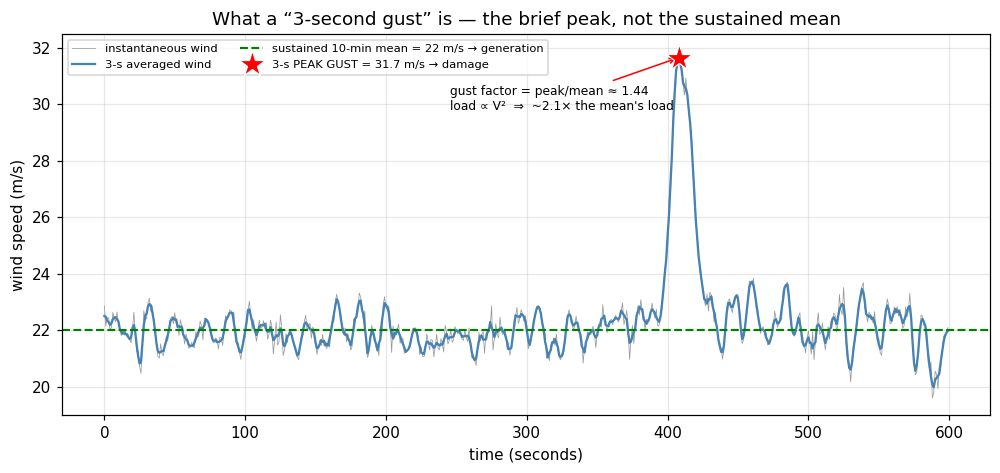

Takeaway: same wind, TWO numbers. The sustained mean (22 m/s) drives GENERATION (resource —
Performance tier). The 3-s peak gust (31.7 m/s, ★) drives structural LOADING (damage — this tier).
Because load ∝ ½ρV², the gust (1.44× the mean) exerts ~2.1× the load — the peak
dominates failure, the mean does not. THIS is why the hazard observable is the 3-s gust (AWN-5), and why
mixing gust with sustained (the old repo's curve-swap, AWN-27) is a category error.


In [3]:
# Schematic — what a "3-second gust" IS vs the sustained mean (a synthetic 10-min open-terrain wind trace).
rng = np.random.default_rng(1)
t = np.arange(0, 600)                                            # 10 minutes @ 1-s sampling
mean_wind = 22.0                                                 # m/s — the 10-min sustained mean
base = pd.Series(rng.normal(0, 1.6, t.size)).rolling(5, center=True, min_periods=1).mean().to_numpy()
bump = 10.0 * np.exp(-((t - 410) / 10.0) ** 2)                  # a single gust event (~24 s wide)
inst = mean_wind + (base - base.mean()) + bump                  # instantaneous wind
gust_3s = pd.Series(inst).rolling(3, center=True, min_periods=1).mean().to_numpy()   # 3-s averaged
pk = int(np.argmax(gust_3s)); peak = gust_3s[pk]
gust_factor = peak / mean_wind
load_ratio = gust_factor ** 2                                   # load ∝ V²

fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(t, inst, lw=0.5, color="0.6", label="instantaneous wind")
ax.plot(t, gust_3s, lw=1.5, color="steelblue", label="3-s averaged wind")
ax.axhline(mean_wind, color="green", ls="--", lw=1.4, label=f"sustained 10-min mean = {mean_wind:.0f} m/s → generation")
ax.plot(pk, peak, "r*", ms=18, mec="white", mew=0.8, zorder=5, label=f"3-s PEAK GUST = {peak:.1f} m/s → damage")
ax.annotate(f"gust factor = peak/mean ≈ {gust_factor:.2f}\nload ∝ V²  ⇒  ~{load_ratio:.1f}× the mean's load",
            (pk, peak), textcoords="offset points", xytext=(-150, -34), fontsize=8,
            arrowprops=dict(arrowstyle="->", color="red", lw=1))
ax.set_xlabel("time (seconds)"); ax.set_ylabel("wind speed (m/s)")
ax.set_title("What a “3-second gust” is — the brief peak, not the sustained mean")
ax.legend(fontsize=7.5, loc="upper left", ncol=2)
plt.tight_layout(); plt.show()
print(f"Takeaway: same wind, TWO numbers. The sustained mean ({mean_wind:.0f} m/s) drives GENERATION (resource —")
print(f"Performance tier). The 3-s peak gust ({peak:.1f} m/s, ★) drives structural LOADING (damage — this tier).")
print(f"Because load ∝ ½ρV², the gust ({gust_factor:.2f}× the mean) exerts ~{load_ratio:.1f}× the load — the peak")
print(f"dominates failure, the mean does not. THIS is why the hazard observable is the 3-s gust (AWN-5), and why")
print(f"mixing gust with sustained (the old repo's curve-swap, AWN-27) is a category error.")

**Provenance — the 3-s gust is a *codified standard*, not our invention.** `[REF]`/`[STD]` It is the official
basis of **ASCE 7** (the US design-wind code) since **ASCE 7-95 (1995)**, when it replaced the older
*fastest-mile* wind speed, and of the **Enhanced Fujita scale** (tornado ratings *are* expressed as 3-s gusts).
It coexists with other averaging conventions, bridged by the **gust factor** (~1.4 in open terrain):

| averaging window | who standardized on it | for what |
|---|---|---|
| **3-second gust** | **ASCE 7 (since 1995), EF scale** | structural **damage** / design loads ← *us* |
| 10-minute mean | **IEC 61400** (Vref), WMO, much of Europe | the reference wind; resource / fatigue |
| 1-minute sustained | US NHC | tropical-cyclone intensity |
| "fastest-mile" | pre-1995 US codes | superseded |

We adopt the 3-s gust (AWN-5) because it is the field's standard **and** our core sources (ASCE maps, the EF
scale) are natively in it — minimizing lossy conversions. *(Nuance: IEC's primary reference Vref is a 10-min
mean; its 50-yr extreme `Ve50 ≈ 1.4·Vref` is the part expressed as a 3-s gust — the gust factor is how we line
IEC's survival speed up to the ASCE/EF 3-s-gust axis.)*

## 3 · The event / catalog threshold μ + the EF bins — what counts as an event (for λ)

A "wind event" crosses a defined severity line set by the **meteorological** standard (not the asset). It feeds
the frequency λ in M1.

In [4]:
# Event-count thresholds μ (the catalog floor, per sub-peril).
MU = {"strong_wind": 58.0, "tornado": 65.0}                       # mph, 3-s gust
print(f"[REF] strong wind μ = {MU['strong_wind']:.0f} mph (≈ {ms(MU['strong_wind']):.1f} m/s) "
      f"— NWS severe-thunderstorm criterion  (old repo: 25.92 m/s)")
print(f"[REF] tornado     μ = {MU['tornado']:.0f} mph (≈ {ms(MU['tornado']):.1f} m/s) "
      f"— EF0 floor (Enhanced Fujita scale, operational since 2007)\n")

# [REF] EF scale bins (3-s gust, mph) — damage-inferred via 28 damage indicators × 8 degrees of damage (AWN-7).
EF = pd.DataFrame([
    ("EF0", 65, 85,  "weakest rated"),
    ("EF1", 86, 110, ""),
    ("EF2", 111, 135, "ASCE Ch-32 tornado design covers ~EF2 and below"),
    ("EF3", 136, 165, ""),
    ("EF4", 166, 200, ""),
    ("EF5", 201, 253, "open-ended (>200 mph); truncated at the physical bound L"),
], columns=["EF", "gust_lo_mph", "gust_hi_mph", "note"])
print(EF.to_string(index=False))
print("\nEF is DAMAGE-INFERRED, not measured — so it is biased LOW where there is little to damage (rural/open")
print("land). Both proving sites (Traverse OK, Shepherds Flat OR) are rural → historical EF severity likely")
print("understated (AWN-7). The catalog μ is a property of the HAZARD; the damage onset (§5) is a property of the")
print("ASSET — keeping them separate is the load-bearing discipline (DD-WN-7).")

[REF] strong wind μ = 58 mph (≈ 25.9 m/s) — NWS severe-thunderstorm criterion  (old repo: 25.92 m/s)
[REF] tornado     μ = 65 mph (≈ 29.1 m/s) — EF0 floor (Enhanced Fujita scale, operational since 2007)

 EF  gust_lo_mph  gust_hi_mph                                                     note
EF0           65           85                                            weakest rated
EF1           86          110                                                         
EF2          111          135          ASCE Ch-32 tornado design covers ~EF2 and below
EF3          136          165                                                         
EF4          166          200                                                         
EF5          201          253 open-ended (>200 mph); truncated at the physical bound L

EF is DAMAGE-INFERRED, not measured — so it is biased LOW where there is little to damage (rural/open
land). Both proving sites (Traverse OK, Shepherds Flat OR) are rural → historical EF

## 4 · The physical upper bound L — where the magnitude distribution ends  `[FRAME]` (AWN-8)

A magnitude distribution running to infinity is unphysical for a single site. We truncate at **L ≈ 113 m/s
(~253 mph)** — a physical ceiling *above* the open-ended EF5 floor (EF5 is `> 200` mph with no upper limit).
This bound is what makes the severity tail **short** (§6).

> **Divergence reconciled (honest, DD-WN-8 / AWN-8).** The old repo used **tornado L = 145 m/s** (Moore-1999
> *observed Doppler max*) and **113 m/s** as its *Strong-Wind* limit (Cyclone Olivia gust). The new build adopts
> the **EF5 damage-inferred ceiling ≈ 113 m/s** for the convective members (the old F-scale F5 midpoint, 111.8
> m/s, corroborates it). 113-vs-145 is a logged decision, not a silent pick. `[FRAME]` — not in the reference.

In [5]:
L_MS = 113.0
L_MPH = mph(L_MS)
print(f"[FRAME] L = {L_MS:.0f} m/s = {L_MPH:.1f} mph  (EF5 ceiling; severity right-truncation)")
print(f"        corroboration: old-repo F5 midpoint 111.8 m/s ≈ {mph(111.8):.0f} mph; old tornado L=145 m/s rejected")

[FRAME] L = 113 m/s = 252.8 mph  (EF5 ceiling; severity right-truncation)
        corroboration: old-repo F5 midpoint 111.8 m/s ≈ 250 mph; old tornado L=145 m/s rejected


## 5 · The TWO thresholds — keep them distinct (the part that trips newcomers)  (AWN-6/9/10, DD-WN-7)

There are **two** wind thresholds and they live in different layers. Collapsing them is the classic error.

```
  METEOROLOGICAL EVENT THRESHOLD  μ              ASSET DAMAGE-ONSET THRESHOLD
  "what the catalog COUNTS"  → feeds λ (M1)       "where the damage curve LEAVES ZERO" → anchors M3
  ────────────────────────────────────           ──────────────────────────────────────────────
  strong wind: NWS ≥ 58 mph (≈ 25.9 m/s)          IEC 61400 survival speed  Ve50 ≈ 1.4·Vref
  tornado:     EF0 ≥ 65 mph                        ≈ 52–70 m/s (≈ 117–157 mph), class III→I
```

A 60-mph gust *is* a severe-wind event the catalog counts — but it is **far below** what damages a modern
turbine. Turbines are engineered to IEC 61400 wind classes; the damage curve is **anchored** so `DR(μ) ≈ 0` and
rises steeply only near the IEC survival speed. **Most "severe wind" barely scratches a turbine.**

In [6]:
# [FRAME] IEC 61400 wind classes — Vref (10-min mean) and Ve50 ≈ 1.4·Vref (50-yr extreme 3-s gust).
IEC = pd.DataFrame([
    ("I",  50.0), ("II", 42.5), ("III", 37.5),
], columns=["class", "Vref_ms"])
IEC["Ve50_ms"] = (1.4 * IEC["Vref_ms"]).round(1)
IEC["Ve50_mph"] = mph(IEC["Ve50_ms"]).round(0)
print(IEC.to_string(index=False))
print(f"\n[FRAME] IEC 61400 / Vref classes / the EF5≈113 m/s ceiling are NOT in the Hazard-Data-Reference — they")
print(f"        come from the standards / old-repo HAZARD_LIMITS (AWN-10). The reference supplies μ=58 mph, the EF")
print(f"        bins, the 3-s-gust metric, and the ASCE surfaces; for turbines it only says 'account for the")
print(f"        survival wind speed + operational state, not just the design speed' — without naming IEC.")
IEC_BAND_MPH = (IEC["Ve50_mph"].min(), IEC["Ve50_mph"].max())   # ~117–157 mph (class III→I)

class  Vref_ms  Ve50_ms  Ve50_mph
    I     50.0     70.0     157.0
   II     42.5     59.5     133.0
  III     37.5     52.5     117.0

[FRAME] IEC 61400 / Vref classes / the EF5≈113 m/s ceiling are NOT in the Hazard-Data-Reference — they
        come from the standards / old-repo HAZARD_LIMITS (AWN-10). The reference supplies μ=58 mph, the EF
        bins, the 3-s-gust metric, and the ASCE surfaces; for turbines it only says 'account for the
        survival wind speed + operational state, not just the design speed' — without naming IEC.


## 6 · The severity model — a *bounded* GPD on gust magnitude (EVT-on-intensity)  (AWN-17, DD-WN-8)

Given an event above μ, how big is the gust? **Extreme-Value Theory on the *intensity***: a Generalized Pareto
Distribution (GPD) on exceedances above μ, **right-bounded at L**. The shape ξ governs the tail —
`ξ>0` heavy/unbounded, `ξ=0` exponential, **`ξ<0` bounded** (a finite upper endpoint). A ceiling L the gust can
actually *approach* forces **ξ < 0** — a *short* tail. **This bounded (ξ<0) form is the TORNADO severity**
(tornado gusts reach the EF5 ceiling). **Strong wind degenerates to ξ ≈ 0 (Gumbel / exponential)** — the M1 build
found its ASCE return-level curve is log-linear and its gusts stay far below L, so the bound barely bites. **ξ<0
is therefore scoped to tornado, not a wind-wide rule** ([m1_catalog](../m1_catalog/01_catalog.ipynb)). We reuse
the old repo's closed-form solve (left-anchor μ, right-bound L, mean-constrained) and **verify it against known
answers** (basics-spot-on):

In [7]:
def bounded_gpd(mu: float, mu_mean: float, L: float):
    """Mean-constrained bounded GPD on [mu, L]. Returns (xi, sigma, frozen scipy dist).

    xi = (mu_mean - mu)/(mu_mean - L)   (< 0 since mu_mean < L  ⇒ bounded, short tail)
    sigma = -xi*(L - mu)
    """
    xi = (mu_mean - mu) / (mu_mean - L)
    sigma = -xi * (L - mu)
    return xi, sigma, genpareto(c=xi, loc=mu, scale=sigma)


# Illustrative TORNADO values (the bounded case; m/s): μ = EF0 floor; μ_mean = mean tornado gust from the EF mix
# (a DEFINITIONAL placeholder; M1 fits it to the real EF record, AWN-18). L = EF5 ceiling. (Strong wind, by
# contrast, fits to ξ≈0 in M1 — the dashed exponential below is essentially its shape.)
mu_ms, mu_mean_ms = ms(65.0), 40.0          # 29.1 m/s (EF0) · 40 m/s — tornado, bounded ξ<0
xi, sigma, dist = bounded_gpd(mu_ms, mu_mean_ms, L_MS)
print(f"μ = {mu_ms:.2f} m/s · μ_mean = {mu_mean_ms:.1f} m/s · L = {L_MS:.0f} m/s")
print(f"⇒ ξ = {xi:.4f}  (negative ⇒ BOUNDED, short tail)   σ = {sigma:.3f}\n")

# Known-answer checks — the analytic solve must reproduce its own constraints exactly:
support_lo, support_hi = dist.support()
checks = {
    "ξ < 0 (bounded tail)":                 xi < 0,
    "support lower endpoint == μ":          np.isclose(support_lo, mu_ms),
    "support upper endpoint == L":          np.isclose(support_hi, L_MS),
    "distribution mean == μ_mean":          np.isclose(dist.mean(), mu_mean_ms),
    "pdf → 0 at the ceiling L":             dist.pdf(L_MS) < 1e-6,
}
for name, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
assert all(checks.values()), "bounded-GPD analytic solve failed a known-answer check"
print(f"\n  (support = [{support_lo:.2f}, {support_hi:.2f}] m/s ; mean = {dist.mean():.2f} m/s — all exact)")

μ = 29.06 m/s · μ_mean = 40.0 m/s · L = 113 m/s
⇒ ξ = -0.1499  (negative ⇒ BOUNDED, short tail)   σ = 12.583

  [PASS] ξ < 0 (bounded tail)
  [PASS] support lower endpoint == μ
  [PASS] support upper endpoint == L
  [PASS] distribution mean == μ_mean
  [PASS] pdf → 0 at the ceiling L

  (support = [29.06, 113.00] m/s ; mean = 40.00 m/s — all exact)


> **Reuse the good part, reject the bad part** (DD-WN-8 / AWN-18). We keep the bounded-GPD analytic solve and
> the `ξ<0` shape. We **reject** the old repo's habit of *back-solving μ_mean from a target EAL* (reverse-
> engineering the magnitude distribution from a desired loss). M1 fits μ_mean to the **observed gust record**
> (SPC/Storm-Events, bias-corrected) — the tail is fit to gusts, never to an answer. Wind also **cashes in the
> continuous-severity thread**: unlike wildfire's 6 discrete flame-length classes, gust is a *continuous*
> magnitude, so this is a genuinely fitted continuous tail.

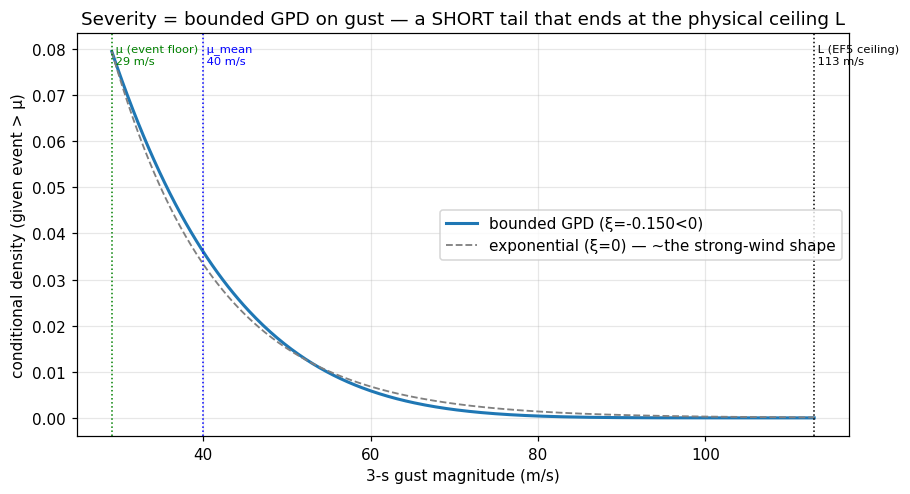

Takeaway: the bounded GPD (ξ<0) puts ZERO mass beyond L — short and physical. This is the TORNADO severity
(gusts reach the EF5 ceiling); STRONG WIND fits ξ≈0 (the dashed exponential, gusts far below L) — M1 confirms
both. M1 fits μ_mean per sub-peril to real gusts, never back-solved from an EAL (AWN-18).


In [8]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
v = np.linspace(mu_ms, L_MS, 400)
ax.plot(v, dist.pdf(v), lw=2, label=f"bounded GPD (ξ={xi:.3f}<0)")
# contrast: an unbounded exponential tail (ξ=0, same σ) — to show what the ceiling removes
exp_dist = genpareto(c=0.0, loc=mu_ms, scale=sigma)
ax.plot(v, exp_dist.pdf(v), lw=1.2, ls="--", color="gray", label="exponential (ξ=0) — ~the strong-wind shape")
for x, lab, col in [(mu_ms, "μ (event floor)", "green"), (mu_mean_ms, "μ_mean", "blue"), (L_MS, "L (EF5 ceiling)", "black")]:
    ax.axvline(x, color=col, ls=":", lw=1)
    ax.text(x, ax.get_ylim()[1]*0.92, f" {lab}\n {x:.0f} m/s", color=col, fontsize=7.5)
ax.set_xlabel("3-s gust magnitude (m/s)"); ax.set_ylabel("conditional density (given event > μ)")
ax.set_title("Severity = bounded GPD on gust — a SHORT tail that ends at the physical ceiling L")
ax.legend(loc="center right")
plt.tight_layout(); plt.show()
print("Takeaway: the bounded GPD (ξ<0) puts ZERO mass beyond L — short and physical. This is the TORNADO severity")
print("(gusts reach the EF5 ceiling); STRONG WIND fits ξ≈0 (the dashed exponential, gusts far below L) — M1 confirms")
print("both. M1 fits μ_mean per sub-peril to real gusts, never back-solved from an EAL (AWN-18).")

## 7 · The ASCE 7-22 RP surface — the severity tail, *already fitted* (for strong wind)  (AWN-15, DD-WN-3)

For **strong wind** there is a shortcut better than fitting our own GPD: the EVT is **already done**. `[REF]`
*"the ASCE design wind-speed maps already contain a probabilistic return-period analysis … use the map RP
surface as the hazard."* The ASCE 7-22 basic-wind map is a **pre-integrated return-period 3-s-gust surface** —
reading several MRIs = sampling the EVT return-level curve at fixed exceedance probabilities (RC I 300-yr / II
700-yr / III 1,700-yr / IV 3,000-yr; Appendix F to ~10⁶-yr). So strong-wind M1 is **profile-assembly, not a fit**
— structurally identical to FSim for wildfire ([learning-09](../../../docs/learning_logs/09_pre_integrated_vs_extracted_catalog.md)).
*The honesty cost:* we inherit ASCE/NIST's assumptions, vintage, and the Exposure-C reference — the uncertainty
*moved upstream*, it did not vanish. **The real surface is read in M0** ([`m0/01_asce_hazard`](../m0_input_data/01_asce_hazard.ipynb));
here we only fix that this *is* the strong-wind severity route. (Tornado has no equivalent — its catalog is fit
from the SPC record, the *extraction* branch.)

## 8 · A coupling-taxonomy primer — *how the hazard reaches the asset*  (DD-WN-4/5/9)

Defining "how strong" is half the job; the other half is **how the hazard reaches the asset** (the *coupling*).
The platform answers with exactly **three buckets**, sorted by the reference's footprint taxonomy
(*point / narrow path / broad swath / regional field*). **Convective wind's two sub-perils** sit in two of them —
tornado (areal) and strong wind (site-conditioned); the third bucket, field-intensity, belongs to the
**separate, deferred hurricane peril**, shown below only for orientation (it shares the 3-s-gust damage curve but
is **not** a convective-wind sub-peril). Touring all three buckets is the "coupling matters" payoff.

In [9]:
buckets = pd.DataFrame([
    ("1. Areal hit-or-miss", "point / narrow path", "full loss IF hit, $0 if missed (bimodal)",
     "Bernoulli × Minkowski (√F+√s)²/A", "tornado [T] · convective wind", "hail ✅ (reuse)"),
    ("2. Field-intensity", "regional field", "a local value, different every event",
     "sample the field per event", "HURRICANE — separate peril (deferred)", "— none yet"),
    ("3. Site-conditioned", "broad swath (pre-integrated)", "its own pre-baked local profile (no miss)",
     "profile-assembly (read it)", "strong wind [W] · convective wind", "wildfire ✅ (reuse)"),
], columns=["bucket", "footprint", "what the asset reads", "math", "peril / sub-peril", "built?"])
with pd.option_context("display.max_colwidth", 40, "display.width", 200):
    print(buckets.to_string(index=False))
print("\nTORNADO → bucket 1 (narrow path; reuse hail's Minkowski, path-aware thin rectangle (L+a)(w+a); rare per")
print("  site → sparse Monte Carlo → report TVaR alongside VaR).")
print("STRONG WIND → bucket 3 (broad swath; the ASCE RP surface IS the pre-integrated profile; reuse wildfire's")
print("  thin M2; high-frequency → well-populated MC). [empirically shown flat-to-0.1mph in m0/01_asce_hazard]")
print("HURRICANE (a SEPARATE, deferred peril — NOT a convective-wind sub-peril) → bucket 2 (regional field; the")
print("  genuinely UNBUILT bucket — portfolio correlation + EVT load-bearing; shares only the 3-s-gust curve). One")
print("  shared compound-Poisson/NegBin engine, untouched, sits behind every peril.")

              bucket                    footprint                      what the asset reads                             math                     peril / sub-peril             built?
1. Areal hit-or-miss          point / narrow path  full loss IF hit, $0 if missed (bimodal) Bernoulli × Minkowski (√F+√s)²/A         tornado [T] · convective wind     hail ✅ (reuse)
  2. Field-intensity               regional field      a local value, different every event       sample the field per event HURRICANE — separate peril (deferred)         — none yet
 3. Site-conditioned broad swath (pre-integrated) its own pre-baked local profile (no miss)       profile-assembly (read it)     strong wind [W] · convective wind wildfire ✅ (reuse)

TORNADO → bucket 1 (narrow path; reuse hail's Minkowski, path-aware thin rectangle (L+a)(w+a); rare per
  site → sparse Monte Carlo → report TVaR alongside VaR).
STRONG WIND → bucket 3 (broad swath; the ASCE RP surface IS the pre-integrated profile; reuse wildfire's
  th

## 9 · The anchored damage-curve concept — `DR(μ) ≈ 0`, rising near IEC survival  (AWN-24/25, DD-WN-11)

The two thresholds (§5) make the damage curve **anchored**: damage onset (IEC survival ~117–157 mph) is *far
above* the event floor (58 mph), so `DR(58 mph) ≈ 0` and the curve rises only near survival, truncated at L.
The schematic below is **illustrative** — M3 builds the real subsystem-weighted, operational-state-aware curve
(the turbine-fragility library). It exists here to *show the shape the definition implies*.

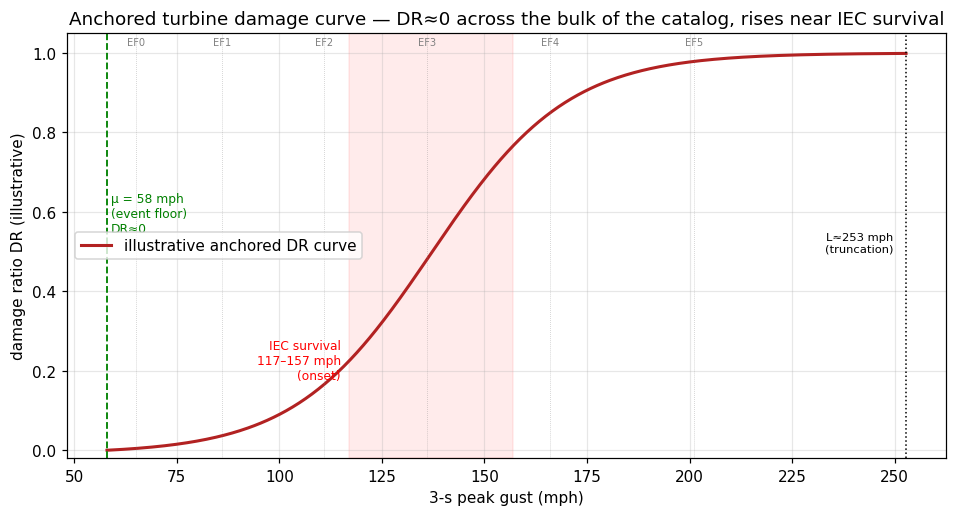

Takeaway: the gap between μ (58 mph) and damage onset (~117–157 mph) is the whole story — frequent severe-
wind events do ~no damage; only the violent tail (EF3+ tornado) reaches destroying gusts. The curve is
ANCHORED accordingly. This shape is the definition's M3 contract; the calibrated curve is built in M3.


In [10]:
v_mph = np.linspace(MU["strong_wind"], L_MPH, 500)
v0 = np.mean(IEC_BAND_MPH)                                   # onset center ≈ mid IEC survival band
k = 0.06                                                     # steepness (illustrative)
DR = 1.0 / (1.0 + np.exp(-k * (v_mph - v0)))
DR = (DR - DR.min()) / (1 - DR.min())                       # anchor DR(μ) → ~0

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(v_mph, DR, lw=2, color="firebrick", label="illustrative anchored DR curve")
ax.axvline(MU["strong_wind"], color="green", ls="--", lw=1.2)
ax.text(MU["strong_wind"]+1, 0.55, "μ = 58 mph\n(event floor)\nDR≈0", color="green", fontsize=8)
ax.axvspan(*IEC_BAND_MPH, color="red", alpha=0.08)
ax.text(IEC_BAND_MPH[0]-2, 0.18, f"IEC survival\n{IEC_BAND_MPH[0]:.0f}–{IEC_BAND_MPH[1]:.0f} mph\n(onset)",
        color="red", fontsize=8, ha="right")
for _, r in EF.iterrows():                                  # EF bin edges as light ticks
    ax.axvline(r.gust_lo_mph, color="gray", ls=":", lw=0.5, alpha=0.5)
    ax.text(r.gust_lo_mph, 1.02, r.EF, fontsize=6.5, color="gray", ha="center")
ax.axvline(L_MPH, color="black", ls=":", lw=1)
ax.text(L_MPH-3, 0.5, f"L≈{L_MPH:.0f} mph\n(truncation)", fontsize=7.5, ha="right")
ax.set_xlabel("3-s peak gust (mph)"); ax.set_ylabel("damage ratio DR (illustrative)")
ax.set_title("Anchored turbine damage curve — DR≈0 across the bulk of the catalog, rises near IEC survival")
ax.set_ylim(-0.02, 1.05); ax.legend(loc="center left")
plt.tight_layout(); plt.show()
print("Takeaway: the gap between μ (58 mph) and damage onset (~117–157 mph) is the whole story — frequent severe-")
print("wind events do ~no damage; only the violent tail (EF3+ tornado) reaches destroying gusts. The curve is")
print("ANCHORED accordingly. This shape is the definition's M3 contract; the calibrated curve is built in M3.")

## 10 · What graduates — the authored layer-0 spec

This notebook fixes the definition the rest of the pipeline consumes:

In [11]:
spec = pd.DataFrame([
    ("magnitude observable", "3-s peak gust @ hub height (elevation/terrain adj = M2)", "[REF]", "AWN-5"),
    ("event threshold μ", "strong wind ≥ 58 mph (≈25.9 m/s) · tornado ≥ 65 mph (EF0)", "[REF]", "AWN-6"),
    ("EF bins (3-s gust)", "EF0 65–85 … EF5 >200 mph; damage-inferred", "[REF]", "AWN-7"),
    ("physical bound L", "EF5 ceiling ≈ 113 m/s (~253 mph); 113-vs-145 reconciled", "[FRAME]", "AWN-8"),
    ("damage-onset (2nd threshold)", "IEC 61400 survival Ve50 ≈ 52–70 m/s (≈117–157 mph)", "[FRAME]", "AWN-9/10"),
    ("severity form", "bounded GPD (ξ<0) on gust, anchored μ, truncated L; μ_mean fit to gusts (not EAL)", "[STD]", "AWN-17/18"),
    ("strong-wind tail route", "ASCE 7-22 RP surface = pre-computed return-level curve (profile-assembly)", "[REF]", "AWN-15"),
    ("operational state", "feathered vs operating modifies the curve — noted, single curve in v1", "[REF]", "AWN-25"),
], columns=["item", "definition", "provenance", "tracks"])
with pd.option_context("display.max_colwidth", 60, "display.width", 220):
    print(spec.to_string(index=False))

                        item                                                                        definition provenance    tracks
        magnitude observable                           3-s peak gust @ hub height (elevation/terrain adj = M2)      [REF]     AWN-5
           event threshold μ                         strong wind ≥ 58 mph (≈25.9 m/s) · tornado ≥ 65 mph (EF0)      [REF]     AWN-6
          EF bins (3-s gust)                                         EF0 65–85 … EF5 >200 mph; damage-inferred      [REF]     AWN-7
            physical bound L                           EF5 ceiling ≈ 113 m/s (~253 mph); 113-vs-145 reconciled    [FRAME]     AWN-8
damage-onset (2nd threshold)                                IEC 61400 survival Ve50 ≈ 52–70 m/s (≈117–157 mph)    [FRAME]  AWN-9/10
               severity form bounded GPD (ξ<0) on gust, anchored μ, truncated L; μ_mean fit to gusts (not EAL)      [STD] AWN-17/18
      strong-wind tail route         ASCE 7-22 RP surface = pre-computed ret

### Findings & carry-forward

- **Wind is authored, not inherited** — μ, the EF bins, L, the severity *form*, and the two-threshold structure
  are now fixed and provenance-tagged. The one piece of real math (the bounded-GPD analytic solve) **passes its
  known-answer checks** (mean == μ_mean, support == [μ, L], ξ<0) — basics-spot-on for the definition.
- **The two thresholds are far apart on purpose** — μ (58 mph) counts events; IEC survival (~117–157 mph) starts
  damage. The curve is anchored; most severe wind does ~no turbine damage. (Shown on real ASCE data in
  [`m0/01_asce_hazard`](../m0_input_data/01_asce_hazard.ipynb) §8b.)
- **Coupling tours all three buckets** — tornado (areal), strong wind (site-conditioned), hurricane (field-
  intensity, deferred). One shared engine behind all three.

**→ M0** ([`m0_input_data/`](../m0_input_data/README.md)): meet the real evidence (ASCE surface ✅ built; SPC
record + asset geometry next) against this definition. **→ M1:** strong wind = profile-assembly off the ASCE
surface (no λ-fit); tornado = bias-corrected SPC fit with this bounded-GPD/EF severity. **→ M3:** the anchored,
IEC-survival-onset turbine curve. **→ M4:** one shared compound-Poisson/NegBin MC, every metric off the sampled
distribution, % of TIV alongside $ — never the expected-loss shortcut (DD-WN-13).